<table align="center" width=100%>
    <tr>
        <td width="15%">
            <img src="in_class.png">
        </td>
        <td>
            <div align="center">
                <font color="#21618C" size=8px>
                    <b> Inclass - Lab <br>(Session 5)
                    </b>
                </font>
            </div>
        </td>
    </tr>
</table>

### About the data set (Employee data)

The dataset contains information about employees. The aim is to find which employees might undergo attrition.<br> Attribute information: 

**Age:** Age of the employee 

**BusinessTravel:** How much travel is involved in the job for the employee:No Travel, Travel Frequently, Tavel Rarely

**Department:** Department of the employee: Human Resources, Reserach & Development, Sales

**Commute:** Number of miles of daily commute for the employee

**Education:** Employee education field: Human Resources, Life Sciences, Marketing, Medical Sciences, Technical, Others

**EnvironmentSatisfaction:** Satisfaction of employee with office environment

**Gender:** Employee gender

**JobInvolvement:** Job involvement rating

**JobLevel:**  Job level for employee designation

**JobSatisfaction:** Employee job satisfaction rating

**MonthlyIncome:** Employee monthly salary

**OverTime:** Has the employee been open to working overtime: Yes or No

**PercentSalaryHike:** Percent increase in salary

**PerformanceRating:** Overall employee performance rating

**YearsAtCompany:** Number of years the employee has worked with the company

**Attrition:** Employee leaving the company: Yes or No

## Table of Content

1. **[Decision tree](#dtree)**
2. **[Random forest](#rf)**

**Import the required libraries**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#### Load the csv file

In [2]:
# load the csv file
df_employee = pd.read_csv('emp_attrition.csv')

# display the first two observations
df_employee.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,YearsAtCompany
0,33,Yes,Travel_Frequently,Research & Development,3,Life Sciences,1,Male,3,1,Research Scientist,1,3348,1,Yes,11,3,10
1,32,Yes,Travel_Rarely,Sales,4,Medical,4,Male,1,3,Sales Executive,4,10400,1,No,11,3,14
2,40,Yes,Travel_Rarely,Research & Development,9,Life Sciences,4,Male,3,1,Laboratory Technician,1,2018,3,No,14,3,5
3,42,No,Travel_Rarely,Research & Development,7,Medical,2,Female,4,2,Research Scientist,2,2372,6,Yes,16,3,1
4,43,No,Travel_Frequently,Research & Development,27,Life Sciences,3,Female,3,3,Manufacturing Director,1,10820,8,No,11,3,8


In [3]:
# Checking Datatypes
df_employee.dtypes

Age                         int64
Attrition                  object
BusinessTravel             object
Department                 object
DistanceFromHome            int64
EducationField             object
EnvironmentSatisfaction     int64
Gender                     object
JobInvolvement              int64
JobLevel                    int64
JobRole                    object
JobSatisfaction             int64
MonthlyIncome               int64
NumCompaniesWorked          int64
OverTime                   object
PercentSalaryHike           int64
PerformanceRating           int64
YearsAtCompany              int64
dtype: object

In [4]:
# Checking Shape of Dataset
df_employee.shape

(1580, 18)

In [5]:
# Descriptive Statistcis
df_employee.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
Age,1580.0,34.339241,8.828037,18.0,28.00,33.0,39.0,60.0
DistanceFromHome,1580.0,9.743671,8.227881,1.0,2.00,8.0,16.0,29.0
EnvironmentSatisfaction,1580.0,2.648734,1.107876,1.0,2.00,3.0,4.0,4.0
JobInvolvement,1580.0,2.660127,0.755176,1.0,2.00,3.0,3.0,4.0
JobLevel,1580.0,1.705696,0.800629,1.0,1.00,2.0,2.0,4.0
JobSatisfaction,1580.0,2.668354,1.105636,1.0,2.00,3.0,4.0,4.0
MonthlyIncome,1580.0,4957.425949,3059.158533,1009.0,2571.75,4148.0,6397.0,16555.0
NumCompaniesWorked,1580.0,2.470886,2.232193,0.0,1.00,1.0,4.0,8.0
PercentSalaryHike,1580.0,13.942405,2.425033,11.0,12.00,13.0,16.0,19.0
PerformanceRating,1580.0,3.000000,0.000000,3.0,3.00,3.0,3.0,3.0


###### Based on the above descriptive statistics, we can say Variables  MonthlyIncome has outliers.
###### For variables Age, DistanceFromHome, , NumCompaniesWorked, YearsAtCompany the difference between 75% & max looks little.
###### Therefore, we will be using boxplot to visualize it.

In [6]:
# Check missing Values
df_employee.isnull().sum()

Age                        0
Attrition                  0
BusinessTravel             0
Department                 0
DistanceFromHome           0
EducationField             0
EnvironmentSatisfaction    0
Gender                     0
JobInvolvement             0
JobLevel                   0
JobRole                    0
JobSatisfaction            0
MonthlyIncome              0
NumCompaniesWorked         0
OverTime                   0
PercentSalaryHike          0
PerformanceRating          0
YearsAtCompany             0
dtype: int64

##### There are no missing values.

**Data Preparation**

In [7]:
# Preparing the feature matrix & target vector

# Feature Matrix
df_features = df_employee.drop(columns=["Attrition"], errors="ignore")

# Splitting Numerical & Categorical Features
df_features_num = df_features.select_dtypes(include=['number'])
df_features_cat = df_features.select_dtypes(include=['object'])

df_target = df_employee["Attrition"]

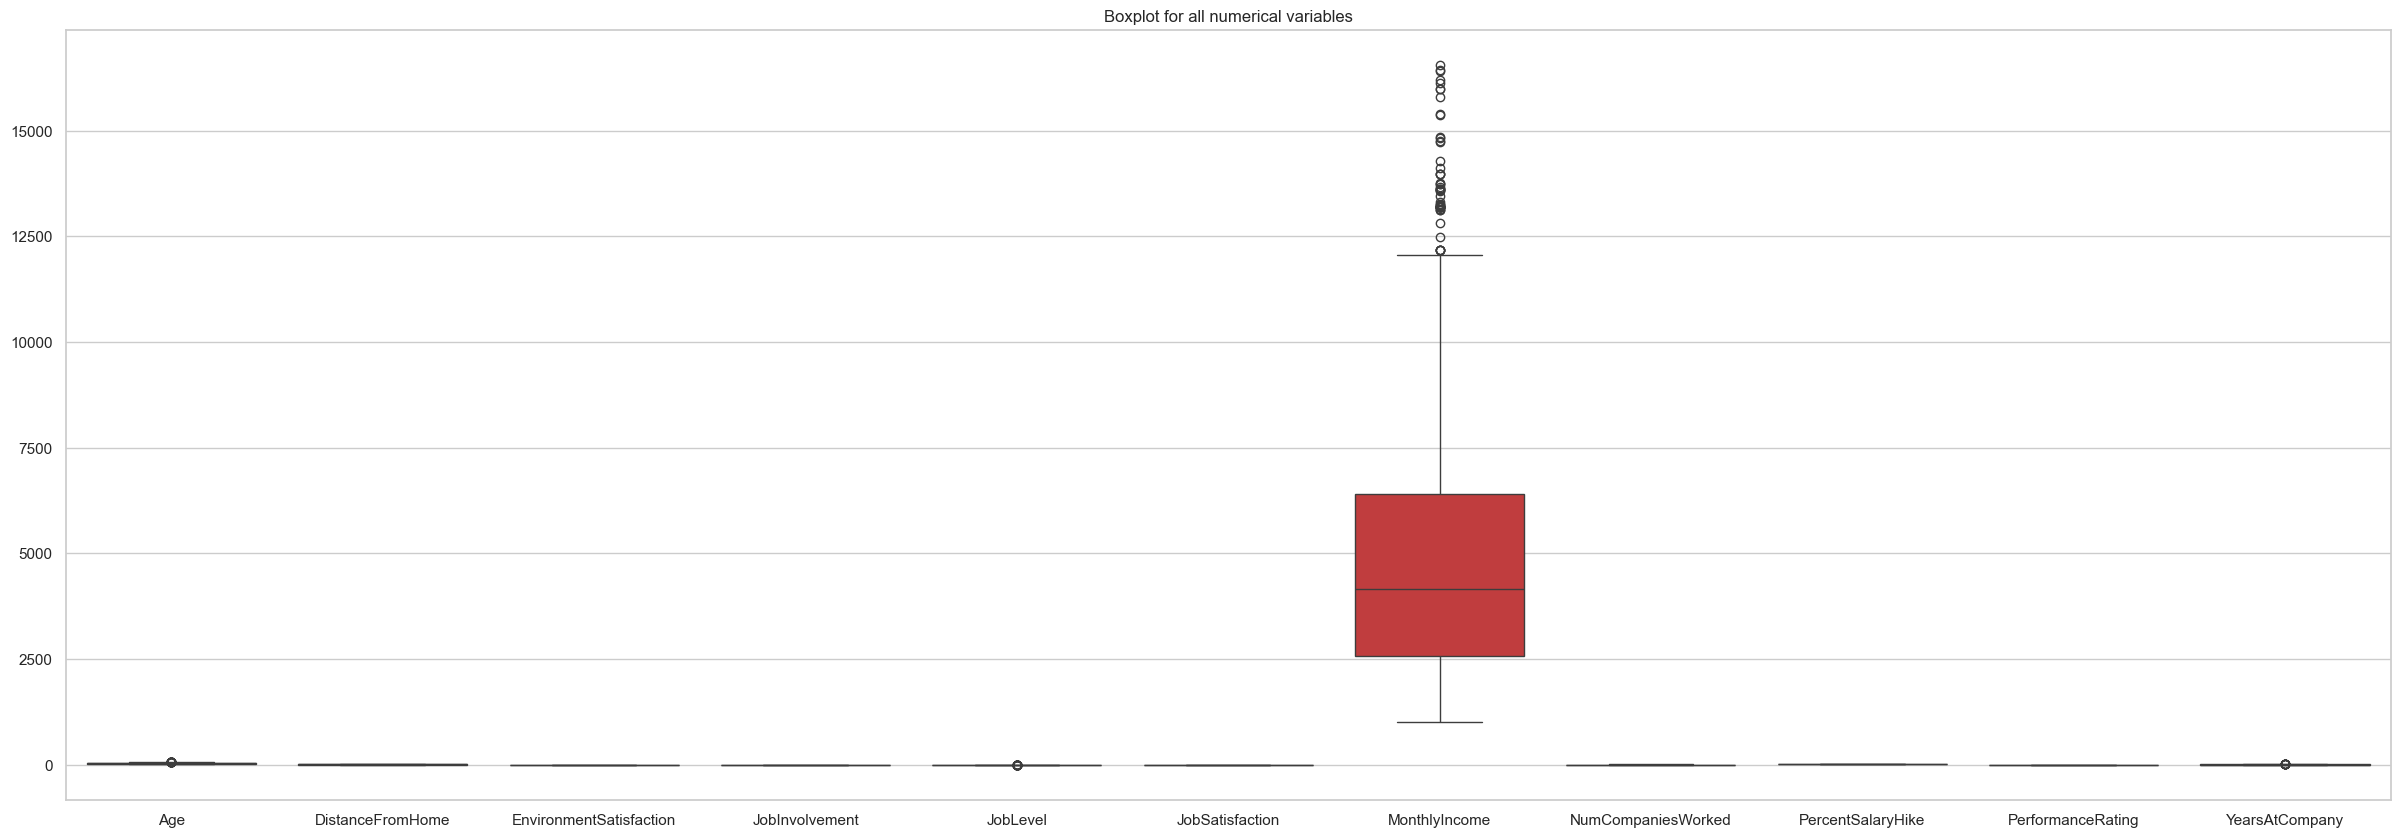

In [8]:
# Visualizing the distribution of data (checking for outliers)
sns.set(style="whitegrid")
plt.figure(figsize=(30,10))
sns.boxplot(data=df_features_num, palette="tab20")
plt.title("Boxplot for all numerical variables")
plt.show()

###### Based on above boxplot we can say that MonthlyIncome variable has outliers, which needs to be treated.

In [9]:
# Outlier treatment for variable MonthlyIncome
Q1, Q3 = np.percentile(df_features_num['MonthlyIncome'], [25,75])
IQR = Q3-Q1
lower_range = Q1 - (1.5*IQR)
upper_range = Q3 + (1.5*IQR)
df_features_num['MonthlyIncome'] = np.where(df_features_num['MonthlyIncome']> upper_range, upper_range,df_features_num['MonthlyIncome'])
df_features_num['MonthlyIncome'] = np.where(df_features_num['MonthlyIncome']< lower_range, lower_range,df_features_num['MonthlyIncome'])


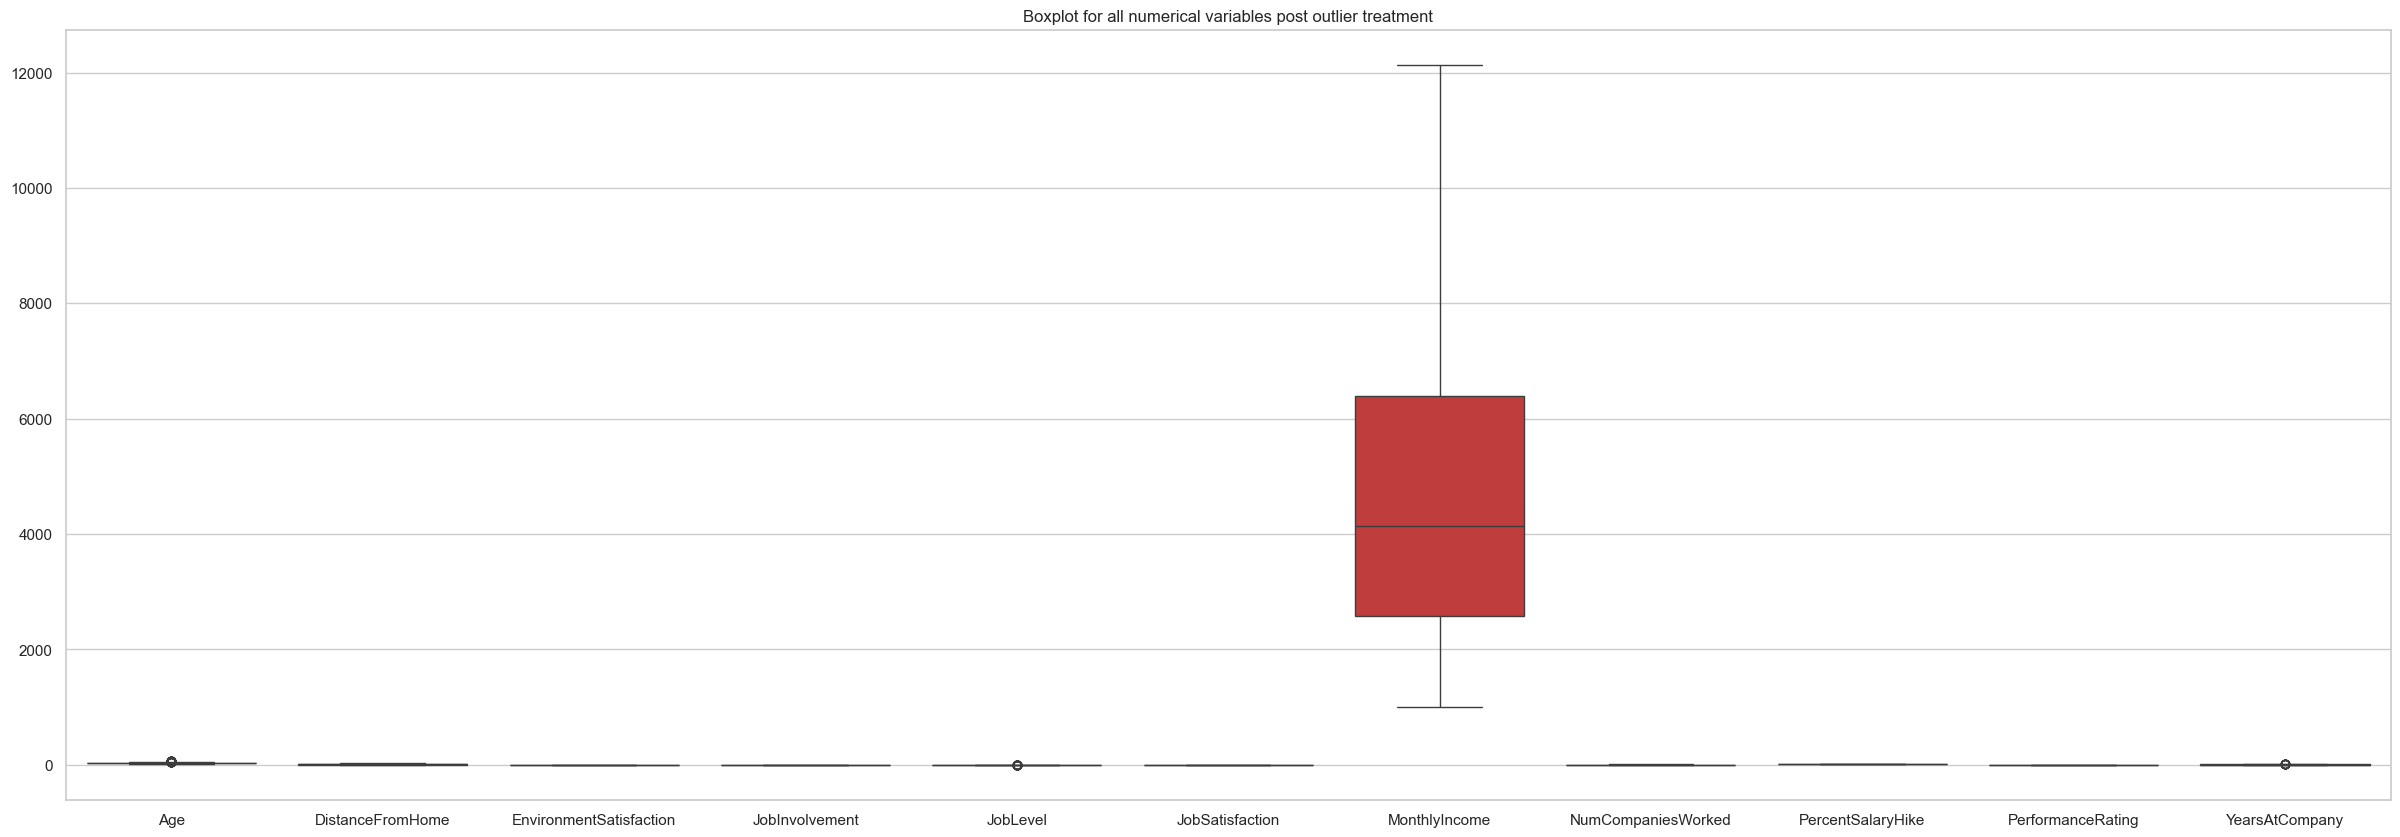

In [10]:
# Visualizing the distribution of data (post outlier treatment)
sns.set(style="whitegrid")
plt.figure(figsize=(30,10))
sns.boxplot(data=df_features_num, palette="tab20")
plt.title("Boxplot for all numerical variables post outlier treatment")
plt.show()

In [11]:
# Encoding the categorical features (One-Hot Encoding)
dummy_var = pd.get_dummies(df_features_cat, drop_first=True)
dummy_var = dummy_var.astype(int)
dummy_var.head()

,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,OverTime_Yes
0,1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,1
1,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0
2,0,1,1,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0
3,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1
4,1,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0


In [12]:
# Encoding the target (One-Hot Encoding)
dummy_target = pd.get_dummies(df_employee['Attrition'], drop_first=True)
dummy_target = dummy_target.astype(int)
dummy_target.head()

,Yes
0,1
1,1
2,1
3,0
4,0


In [13]:
y = dummy_target
X = pd.concat([df_features_num, dummy_var], axis=1)

In [14]:
# Train Test Split

from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>1. Write a code to deal with the imbalanced dataset.</b>
                </font>
            </div>
        </td>
    </tr>
</table>

In [15]:
# Checking Imbalance
att_class_counts = df_employee['Attrition'].value_counts()
print("Attrition Counts:", att_class_counts)

att_class_counts_perc = att_class_counts / len(df_employee) *100
print("Attrition Counts Percentage(%):", att_class_counts_perc)

Attrition Counts: Attrition
No     880
Yes    700
Name: count, dtype: int64
Attrition Counts Percentage(%): Attrition
No     55.696203
Yes    44.303797
Name: count, dtype: float64


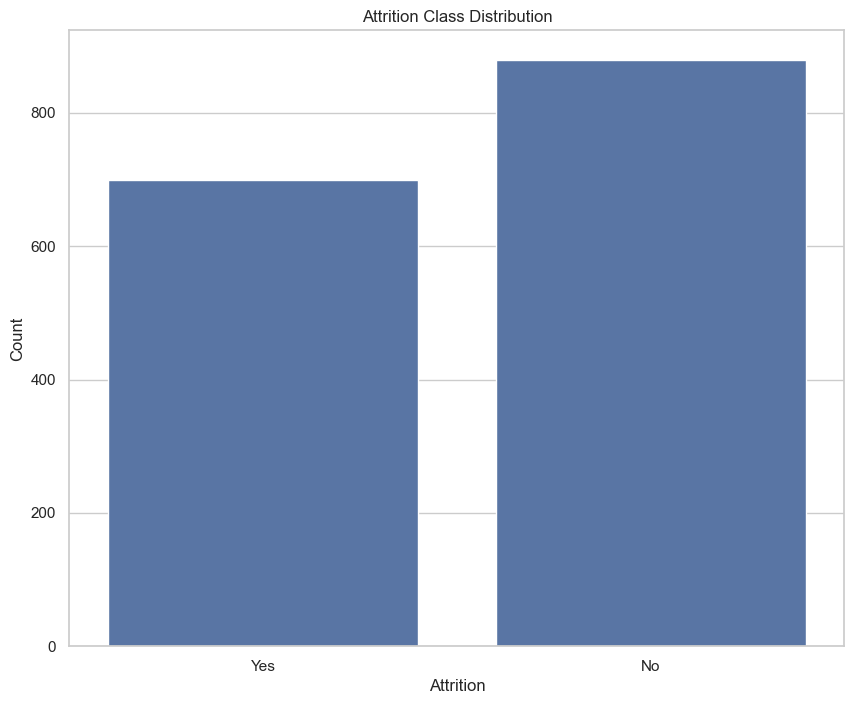

In [16]:
# Visualizing Imbalance
plt.figure(figsize=(10,8))
sns.countplot(data=df_employee, x='Attrition')
plt.title("Attrition Class Distribution")
plt.ylabel('Count')
plt.show()

##### From above countplot we can see that, there is an imbalance in Dataset for Attrition Class Distribution. 
##### Therefore, we will be applying SMOTE to bring balance to the Attrition Class Distribution.


In [17]:
# Handle Imbalance Using SMOTE (Oversampling the Minority Class)
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

In [18]:
# Check the class distribution after applying SMOTE
y_train_balanced.value_counts()

Yes
0      708
1      708
Name: count, dtype: int64

In [19]:
##### Class Imabalance treatment completed.

### Let's begin with some hands-on practice exercises

<a id="dtree"> </a>
## 1. Decision tree

## We shall use the employee dataset

<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>2. Build a model to predict whether or not an employee will leave the company based on employee's environment satisfaction and monthly income. Calculate the accuracy for the model.</b>
                </font>
            </div>
        </td>
    </tr>
</table>

In [20]:
# Creating new feature matrix 
X1 = X_train_balanced[['MonthlyIncome', 'EnvironmentSatisfaction']]
y1 = y_train_balanced

# Train Test Split
X1_train, X1_test, y1_train,y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)


In [21]:
# Decison Tree Classification
from sklearn.tree import DecisionTreeClassifier, plot_tree
model = DecisionTreeClassifier(criterion='gini', random_state=42)

# Train Model
model.fit(X1_train, y1_train)

DecisionTreeClassifier(random_state=42)

In [22]:
from sklearn.metrics import classification_report, accuracy_score

y1_pred = model.predict(X1_test)

report = classification_report(y1_test, y1_pred, target_names=["Yes","No"])
print("Classification Report of Decision Tree:\n", report)

accuracy = accuracy_score(y1_test,y1_pred)
print("Accuracy of Decision Tree:\n", accuracy)


Classification Report of Decision Tree:
               precision    recall  f1-score   support

         Yes       0.93      0.73      0.81       154
          No       0.74      0.93      0.83       130

    accuracy                           0.82       284
   macro avg       0.83      0.83      0.82       284
weighted avg       0.84      0.82      0.82       284

Accuracy of Decision Tree:
 0.8204225352112676


<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>3. Build a full model to predict if an employee will leave the company. Find three features that impact the model prediction the most.</b>
                </font>
            </div>
        </td>
    </tr>
</table>

In [23]:
# Using the feature matrix with all features and creating a new model
X2 = X_train_balanced
y2 = y_train_balanced
print(X2.shape)
print(y2.shape)

# Train Test Split
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Decision Tree Model
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

# Training the Model
dt.fit(X2_train, y2_train)

# Finding top 3 impacting features
feature_importances = pd.DataFrame({
    'Feature': X2.columns,
    'Importance': dt.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop 3 Features Impacting the Model:")
print(feature_importances.head(3))

(1416, 30)
(1416, 1)

Top 3 Features Impacting the Model:
           Feature  Importance
6    MonthlyIncome    0.187503
0              Age    0.143283
10  YearsAtCompany    0.081955


<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>4.  Find the area under the receiver operating characteristic curve for full model built in question 3. </b>
                </font>
            </div>
        </td>
    </tr>
</table>

In [24]:
# Import AUC ROC 
from sklearn.metrics import roc_curve, auc

y2_pred_proba = dt.predict_proba(X2_test)[:,1]

# Calculate the AUC ROC
fpr, tpr, thresholds = roc_curve(y2_test, y2_pred_proba)
roc_auc = auc(fpr,tpr)

print("Area Under the ROC Curve (AUC):", roc_auc)

Area Under the ROC Curve (AUC): 0.8626873126873127


<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>5. Plot a confusion matrix for the full model built in Q3.</b>
                </font>
            </div>
        </td>
    </tr>
</table>

In [25]:
y2_pred = dt.predict(X2_test)

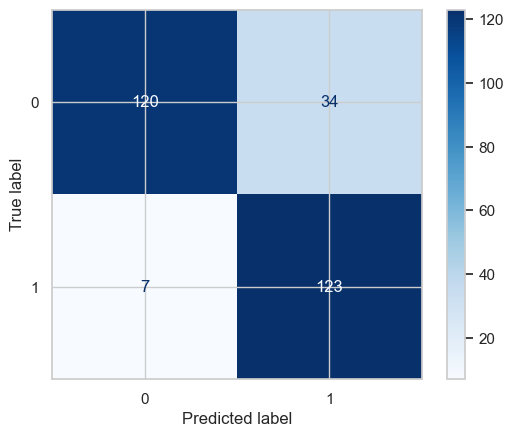

In [26]:
# Importing Confusion Matrix 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

conf_matrix = confusion_matrix(y2_test, y2_pred)

# Printing Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)


<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>6. Calculate the specificity, sensitivity, % of misclassified and correctly classified observations. What can you say about the model by looking at the sensitivity and specificity values? Is this a good model?</b>
                </font>
            </div>
        </td>
    </tr>
</table>

In [27]:
# Extract TP, TN, FP, FN from the confusion matrix
TN, FP, FN, TP = conf_matrix.ravel()  # Unpack the values

# Calculate Sensitivity (Recall)
sensitivity = TP / (TP + FN)

# Calculate Specificity
specificity = TN / (TN + FP)

# Calculate Correctly Classified Percentage
correctly_classified = (TP + TN) / (TP + TN + FP + FN) * 100

# Calculate Misclassified Percentage
misclassified = (FP + FN) / (TP + TN + FP + FN) * 100

print(f"\nSensitivity (Recall): {sensitivity:.2f}")
print(f"Specificity: {specificity:.2f}")
print(f"Percentage of Correctly Classified Observations: {correctly_classified:.2f}%")
print(f"Percentage of Misclassified Observations: {misclassified:.2f}%")


Sensitivity (Recall): 0.95
Specificity: 0.78
Percentage of Correctly Classified Observations: 85.56%
Percentage of Misclassified Observations: 14.44%


##### Observation:
###### - Model has high Sensitivity 95% and fairly good Specificity 79%.
###### - A good model has balanced sensitivity and specificity. Therefore we can conclude this is a good model.

<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>7. Build and plot a decision tree with maximum 5 terminal nodes.</b>
                </font>
            </div>
        </td>
    </tr>
</table>

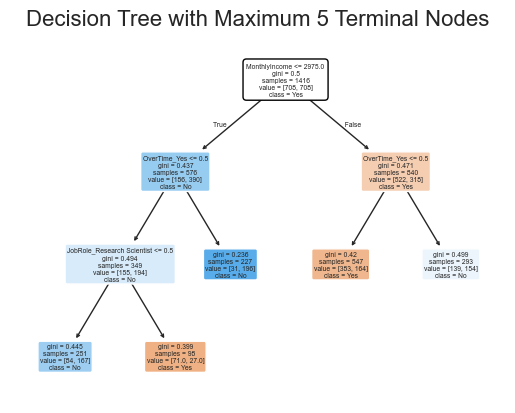

In [28]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Build a Decison Tree with max 5 leaf/terminal nodes
dt2 = DecisionTreeClassifier(max_leaf_nodes=5, random_state=42)

dt2.fit(X_train_balanced, y_train_balanced)

# Fteching Feature Names and Class Names for visulaizing Decision Tree
f_names = X.columns.tolist()
c_names = df_target.unique().astype(str)

# Visualizing Decision Tree
plot_tree(dt2, feature_names=f_names, class_names=c_names, filled=True, rounded=True)
plt.gca().texts[0].set_bbox(dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))
plt.title("Decision Tree with Maximum 5 Terminal Nodes", fontsize=16)
plt.show()

<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>8. Build a Decision Tree model with the predefined parameters and find the average accuracy by performing the 10 fold cross validation.</b>
                </font>
            </div>
        </td>
    </tr>
</table>

In [29]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report

# Build a new Decision Tree
dt3 = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)

dt3.fit(X_train_balanced, y_train_balanced)

# Calculate Accuracy Scores for Cross Validation
accuracy_scores = cross_val_score(dt3, X_train_balanced, y_train_balanced, cv=10, scoring='accuracy')

# Calculate Average Accuracy Scores
average_accuracy = accuracy_scores.mean()

print("Average Accuracy Score by performing 10 fold cross validation:", average_accuracy)



Average Accuracy Score by performing 10 fold cross validation: 0.6857207072220557


<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>9. For a decision tree model, find the best value of hyperparameters "criterion", "max_depth", and "min_samples_split".</b>
                </font>
            </div>
        </td>
    </tr>
</table>

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Create a Decision Tree with default parameters
dt5 = DecisionTreeClassifier(random_state=42)

# Hyperparameter for the param_grid dictionary
param_grid = {
    'criterion': ['gini', 'entropy'],  
    'max_depth': [3, 5, 7, None],  
    'min_samples_split': [2, 5, 7],  
}

# Perform GridSearch with Cross-Validation
grid_search = GridSearchCV(estimator=dt5, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_balanced, y_train_balanced)

# Best Parameters & Accuracy Score
print("Best Hyperparameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)


Best Hyperparameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2}
Best Accuracy: 0.8869780520579307


<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                        <b>10. Build a decision tree model using the tuned hyperparameters, perform 10 fold cross validation and get the average ROC-AUC score.</b>
                </font>
            </div>
        </td>
    </tr>
</table>

In [31]:
# Importing Cross Validation
from sklearn.model_selection import cross_val_score

# Building Decision Tree 
dt6 = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_split=2, random_state=42)

# Model Training
dt6.fit(X_train_balanced, y_train_balanced)

# Calculate ROC AUC Score with 10 fold Cross Validation
roc_auc_scores = cross_val_score(dt6,X_train_balanced, y_train_balanced, cv=10, scoring='roc_auc')

# Calculate Average ROC AUC Score
avg_roc_auc_scores = roc_auc_scores.mean()

print("Average ROC AUC Score with 10 fold Cross Validation:", avg_roc_auc_scores)


Average ROC AUC Score with 10 fold Cross Validation: 0.8899396378269617


<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>11. Build 5 decision trees each with random 20 features. Also predict the attrition for test set for each model.</b>
                </font>
            </div>
        </td>
    </tr>
</table>

In [32]:
import random
from sklearn.model_selection import train_test_split

X7=X_train_balanced
y7=y_train_balanced

X7_train, X7_test, y7_train, y7_test = train_test_split(X7, y7, test_size=0.3, random_state=42)

# Build 5 Random Decision Trees
num_models = 5
num_features = 20
feature_columns = X7.columns.tolist()  # Get the list of all feature names
predictions = []  # Store predictions for each model
selected_features_list = []  # Store selected features for each model

for i in range(num_models):
    # Randomly select 20 features
    random_features = random.sample(feature_columns, num_features)
    selected_features_list.append(random_features)
    
    # Create and train the decision tree using the selected features
    dt7 = DecisionTreeClassifier(random_state=i)
    dt7.fit(X7[random_features], y7)
    
    # Predict on the corresponding subset of test features
    y7_pred = dt7.predict(X7_test[random_features])
    predictions.append(y7_pred)
    
    print(f"Model {i+1}: Features Used -> {random_features}\n")

# Step 4: Display Predictions
predictions_df = pd.DataFrame(predictions).T  # Transpose for better readability
predictions_df.columns = [f'Model_{i+1}_Prediction' for i in range(num_models)]
predictions_df['Actual'] = y7_test.values  # Include actual values for comparison

Model 1: Features Used -> ['JobLevel', 'JobRole_Human Resources', 'EducationField_Medical', 'JobRole_Laboratory Technician', 'OverTime_Yes', 'PercentSalaryHike', 'JobRole_Research Director', 'JobRole_Manufacturing Director', 'Department_Sales', 'Department_Research & Development', 'EducationField_Other', 'EducationField_Marketing', 'MonthlyIncome', 'JobRole_Manager', 'DistanceFromHome', 'PerformanceRating', 'JobRole_Research Scientist', 'Gender_Male', 'Age', 'JobRole_Sales Representative']

Model 2: Features Used -> ['JobRole_Research Director', 'PercentSalaryHike', 'JobRole_Manager', 'JobRole_Laboratory Technician', 'JobRole_Sales Executive', 'EducationField_Other', 'EducationField_Technical Degree', 'JobRole_Research Scientist', 'Department_Sales', 'BusinessTravel_Travel_Frequently', 'JobRole_Sales Representative', 'Age', 'Department_Research & Development', 'JobSatisfaction', 'JobInvolvement', 'EducationField_Medical', 'DistanceFromHome', 'EducationField_Life Sciences', 'JobLevel', 

<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>12. Create a new dataframe "model_predictions_df" by appending each prediction made in question 8. There will be 5 columns in the dataframe for each prediction using the decision tree models built in above question.</b>
                </font>
            </div>
        </td>
    </tr>
</table>

In [33]:
# Create model_predictions_df by storing predictions from all 5 models
model_predictions_df = predictions_df

# Display the DataFrame
print("\nModel Predictions DataFrame:")
model_predictions_df.head()


Model Predictions DataFrame:


,Model_1_Prediction,Model_2_Prediction,Model_3_Prediction,Model_4_Prediction,Model_5_Prediction,Actual
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,1,1,1,1,1,1
4,1,1,1,1,1,1


<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>13. Create a new column "Voted_Result" in the dataframe "model_predictions_df" that contains the maximum occuring value (mode) of the 5 columns in the dataframe (row-wise).<br></b>
                </font>
            </div>
        </td>
    </tr>
</table>

In [34]:
# Calculate the row-wise mode (most frequently occurring value) of the prediction columns
model_predictions_df['Voted_Result'] = model_predictions_df[
    [f'Model_{i+1}_Prediction' for i in range(num_models)]  # Select prediction columns
].mode(axis=1)[0]  # Take the first mode value (in case of ties)

# Display the updated DataFrame
print("\nUpdated Model Predictions DataFrame with Voted_Result:")
model_predictions_df.head()


Updated Model Predictions DataFrame with Voted_Result:


,Model_1_Prediction,Model_2_Prediction,Model_3_Prediction,Model_4_Prediction,Model_5_Prediction,Actual,Voted_Result
0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0
3,1,1,1,1,1,1,1
4,1,1,1,1,1,1,1


<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>14. Consider the values of "Voted_Result" as our new predictions and store its values in a variable "new_y_pred" and find the accuracy and the roc-auc score using new_y_pred.</b>
                </font>
            </div>
        </td>
    </tr>
</table>

In [35]:
new_y_pred = model_predictions_df['Voted_Result']

from sklearn.metrics import accuracy_score, roc_auc_score

accuracy_score = accuracy_score(model_predictions_df['Actual'], new_y_pred)
print("Accuracy Score:", accuracy_score)

roc_auc_score = roc_auc_score(model_predictions_df['Actual'], new_y_pred)
print("AUC ROC Score:", roc_auc_score)


Accuracy Score: 1.0
AUC ROC Score: 1.0


<a id="rf"> </a>
## 2. Random Forest

<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>15. Build a random forest full model to predict if an employee will leave the company or not and generate a classification report.</b>
                </font>
            </div>
        </td>
    </tr>
</table>

In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X8 = X_train_balanced
y8 = y_train_balanced 

X8_train, X8_test, y8_train, y8_test = train_test_split(X8, y8, test_size=0.3, random_state=42)

y8_train = y8_train.values.ravel()  
y8_test = y8_test.values.ravel() 


rf  = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)

rf.fit(X8_train, y8_train)

y8_pred = rf.predict(X8_test)

classification_report = classification_report(y8_pred, y8_test)

print("Classification Report:", classification_report)

Classification Report:               precision    recall  f1-score   support

           0       0.88      0.95      0.92       216
           1       0.94      0.87      0.91       209

    accuracy                           0.91       425
   macro avg       0.91      0.91      0.91       425
weighted avg       0.91      0.91      0.91       425



<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>16. For a random forest model, find the best value of hyperparameters "n_estimators", "criterion", "max_depth", and "min_samples_split".</b>
                </font>
            </div>
        </td>
    </tr>
</table>

In [59]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split

X9 = X_train_balanced
y9 = y_train_balanced

y9 = y9.values.ravel() 

X9_train, X9_test, y9_train, y9_test = train_test_split(X9, y9, test_size=0.3, random_state=42)

rf1 = RandomForestClassifier(random_state=42)

param_grid={
    'n_estimators': [20, 40, 80],  
    'criterion': ['gini', 'entropy'],  
    'max_depth': [3, 5, 10, None],  
    'min_samples_split': [2, 5, 10]  
}

gs1 = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
gs1.fit(X9_train, y9_train)

# Print the best parameters and best score
print("Best Hyperparameters:", gs1.best_params_)
print("Best Accuracy:", gs1.best_score_)



Best Hyperparameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 40}
Best Accuracy: 0.9222831328358966


<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>17. Build a random forest model using the tuned hyperparameters, perform 10 fold cross validation and get the average ROC-AUC score.</b>
                </font>
            </div>
        </td>
    </tr>
</table>

In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rf2 = RandomForestClassifier(
    n_estimators=40,           # Tuned hyperparameter: number of decision trees
    criterion='gini',           # Tuned splitting criterion: gini impurity
    max_depth=None,             # Tuned hyperparameter: unrestricted tree depth
    min_samples_split=2,        # Minimum number of samples required to split a node
    random_state=42             # For reproducibility
)

rf2.fit(X9_train, y9_train)

roc_auc_score = cross_val_score(rf2, X9, y9, cv=10, scoring='roc_auc')

roc_auc_score_avg = roc_auc_score.mean()

print(roc_auc_score_avg)

0.9814127015614815


<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>18. Using the tuned random forest model, find the features that impact the model prediction the most.</b>
                </font>
            </div>
        </td>
    </tr>
</table>

In [68]:
feature_importances = rf2.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)


top_features = importance_df.head(3)
print("Top 3 Features:", top_features)

Top 3 Features:            Feature  Importance
6    MonthlyIncome    0.140526
0              Age    0.122303
10  YearsAtCompany    0.100497


<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>19. Build a random forest model using the top 10 most important features.</b>
                </font>
            </div>
        </td>
    </tr>
</table>

In [40]:
# type your code here

<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>20. Plot a confusion matrix and area under the receiver operating characteristic curve for the model built in question 19. </b>
                </font>
            </div>
        </td>
    </tr>
</table>

In [41]:
# type your code here